In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

warnings.filterwarnings("ignore")

plt.style.use("default")

plt.rcParams["figure.figsize"]=(10,6)

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [3]:
# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv("../Data/train_2000_2020.csv")

validation_df = pd.read_csv("../Data/validation_2021_2022.csv")

prediction_df = pd.read_csv("../Data/test_2023_2025.csv")

print("Train :",train_df.shape)

print("Validation :",validation_df.shape)

print("Prediction :",prediction_df.shape)

Train : (9619, 28)
Validation : (580, 28)
Prediction : (1392, 28)


In [4]:
# ============================================================
# DATA INFORMATION
# ============================================================

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              9619 non-null   str    
 1   Time              9619 non-null   str    
 2   SI                8001 non-null   float64
 3   LI                8001 non-null   float64
 4   LI_V              8001 non-null   float64
 5   SWEAT             7584 non-null   float64
 6   KI                8001 non-null   float64
 7   CT                8001 non-null   float64
 8   VT                8001 non-null   float64
 9   TT                8001 non-null   float64
 10  CAPE              9588 non-null   float64
 11  CAPE_V            9588 non-null   float64
 12  CIN               9588 non-null   float64
 13  CIN_V             9588 non-null   float64
 14  EL                3551 non-null   float64
 15  EL_V              3274 non-null   float64
 16  LFC               7969 non-null   float64
 17  LFC_V 

In [5]:
# ============================================================
# DATASET SUMMARY
# ============================================================

summary = pd.DataFrame({

    "Rows":[

        train_df.shape[0],
        validation_df.shape[0],
        prediction_df.shape[0]

    ],

    "Columns":[

        train_df.shape[1],
        validation_df.shape[1],
        prediction_df.shape[1]

    ]

},

index=[

"Training",

"Validation",

"Prediction"

])

display(summary)

,Rows,Columns
Training,9619,28
Validation,580,28
Prediction,1392,28


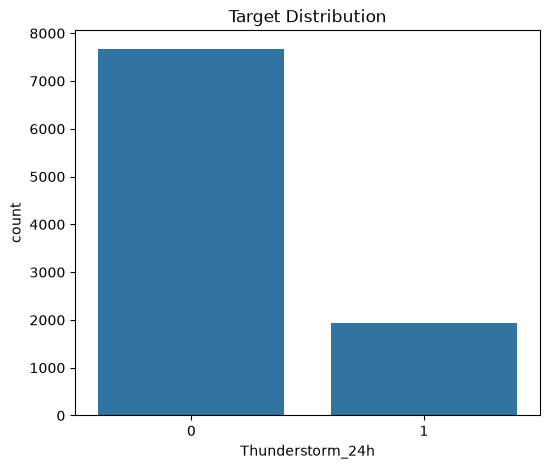

Thunderstorm_24h
0    7674
1    1945
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(6,5))

sns.countplot(

x="Thunderstorm_24h",

data=train_df

)

plt.title("Target Distribution")

plt.show()

print(train_df["Thunderstorm_24h"].value_counts())

In [7]:
class_percent = train_df["Thunderstorm_24h"].value_counts(normalize=True)*100

display(class_percent)

Thunderstorm_24h
0    79.779603
1    20.220397
Name: proportion, dtype: float64

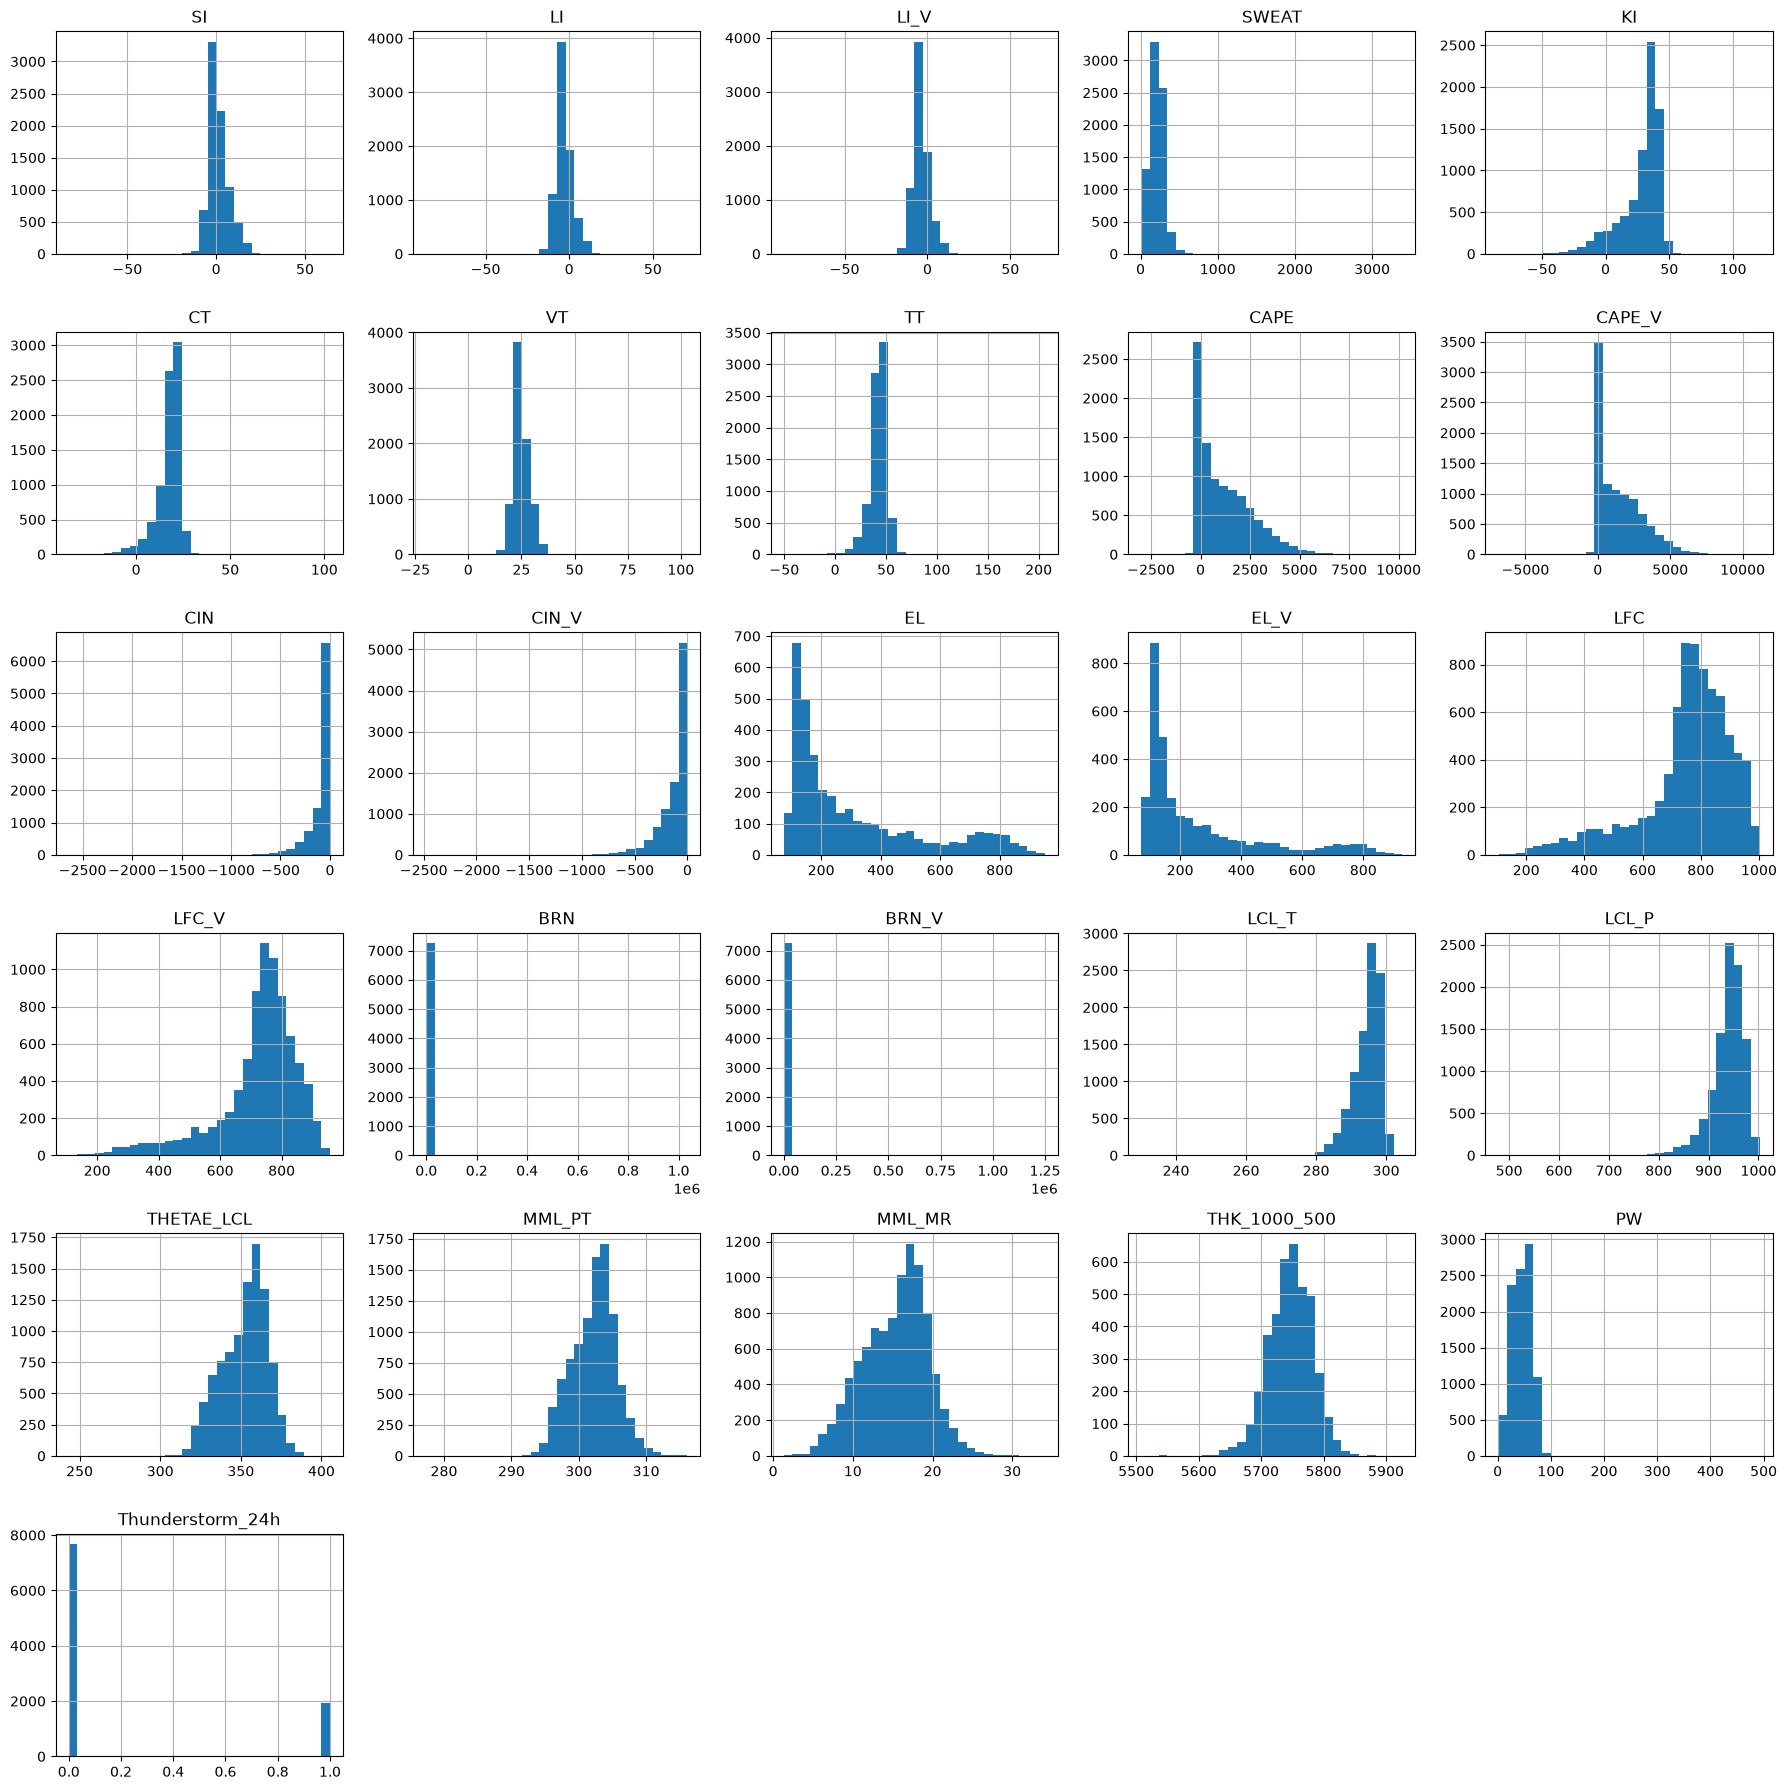

In [8]:
train_df.hist(

figsize=(18,18),

bins=30

)

plt.tight_layout()

plt.show()

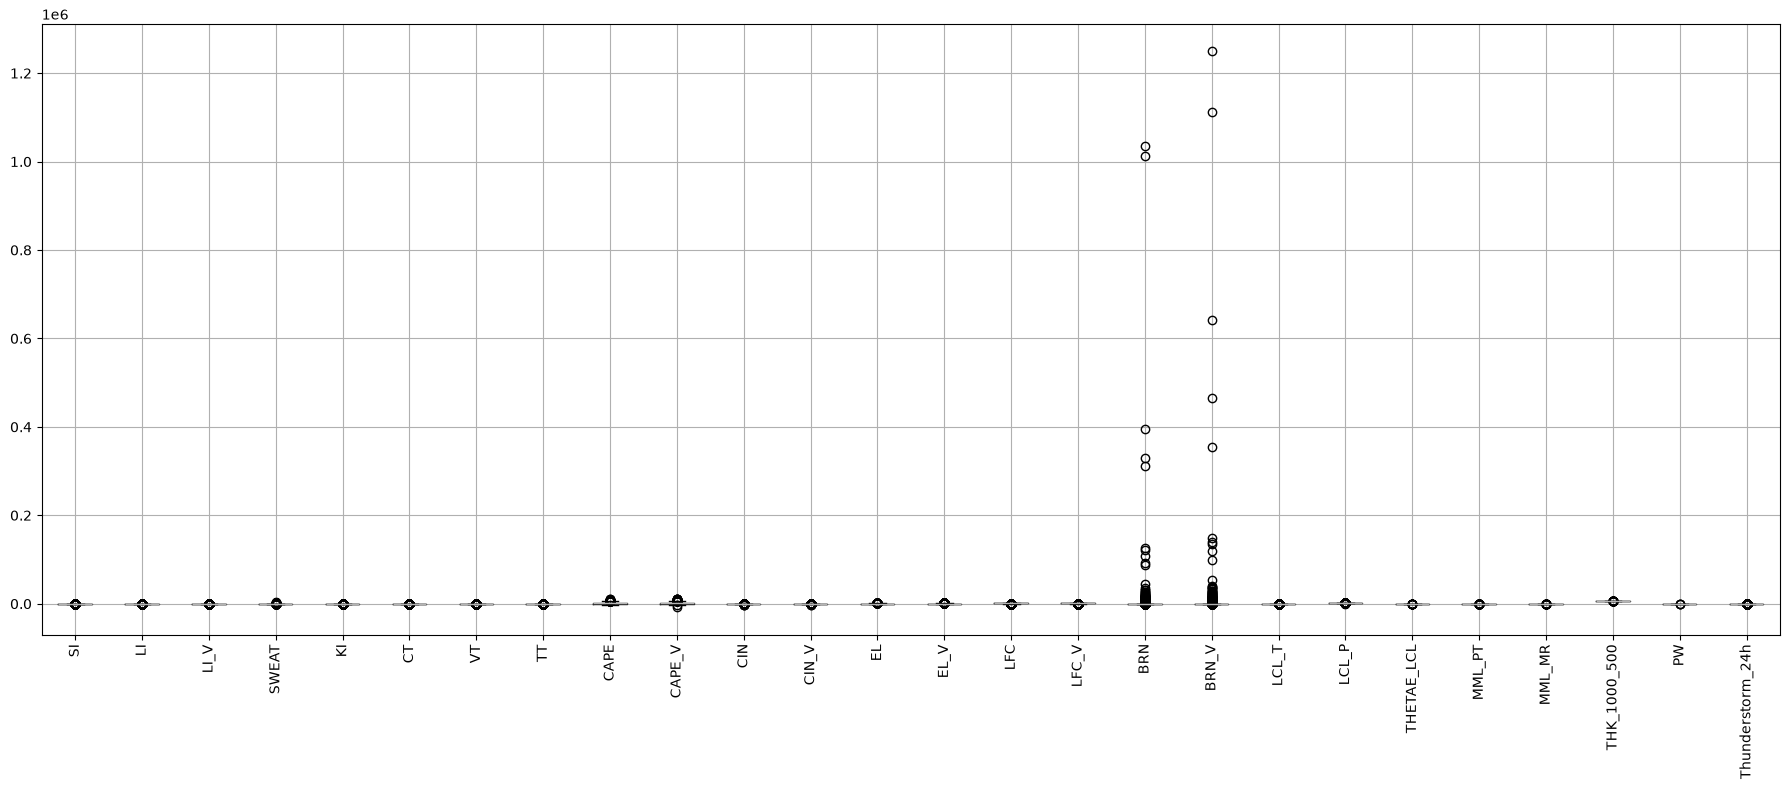

In [9]:
plt.figure(figsize=(18,8))

train_df.boxplot(

rot=90

)

plt.tight_layout()

plt.show()

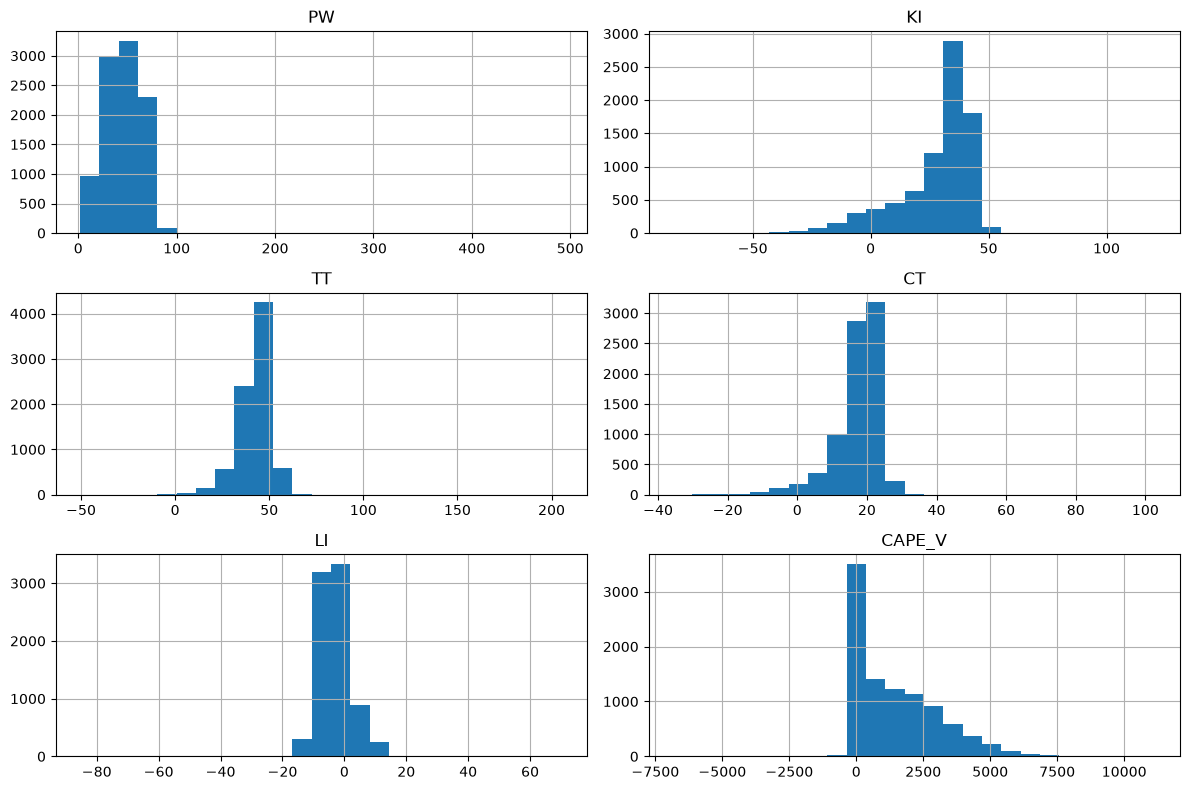

In [10]:
important = [

"PW",

"KI",

"TT",

"CT",

"LI",

"CAPE_V"

]

train_df[important].hist(

figsize=(12,8),

bins=25

)

plt.tight_layout()

plt.show()

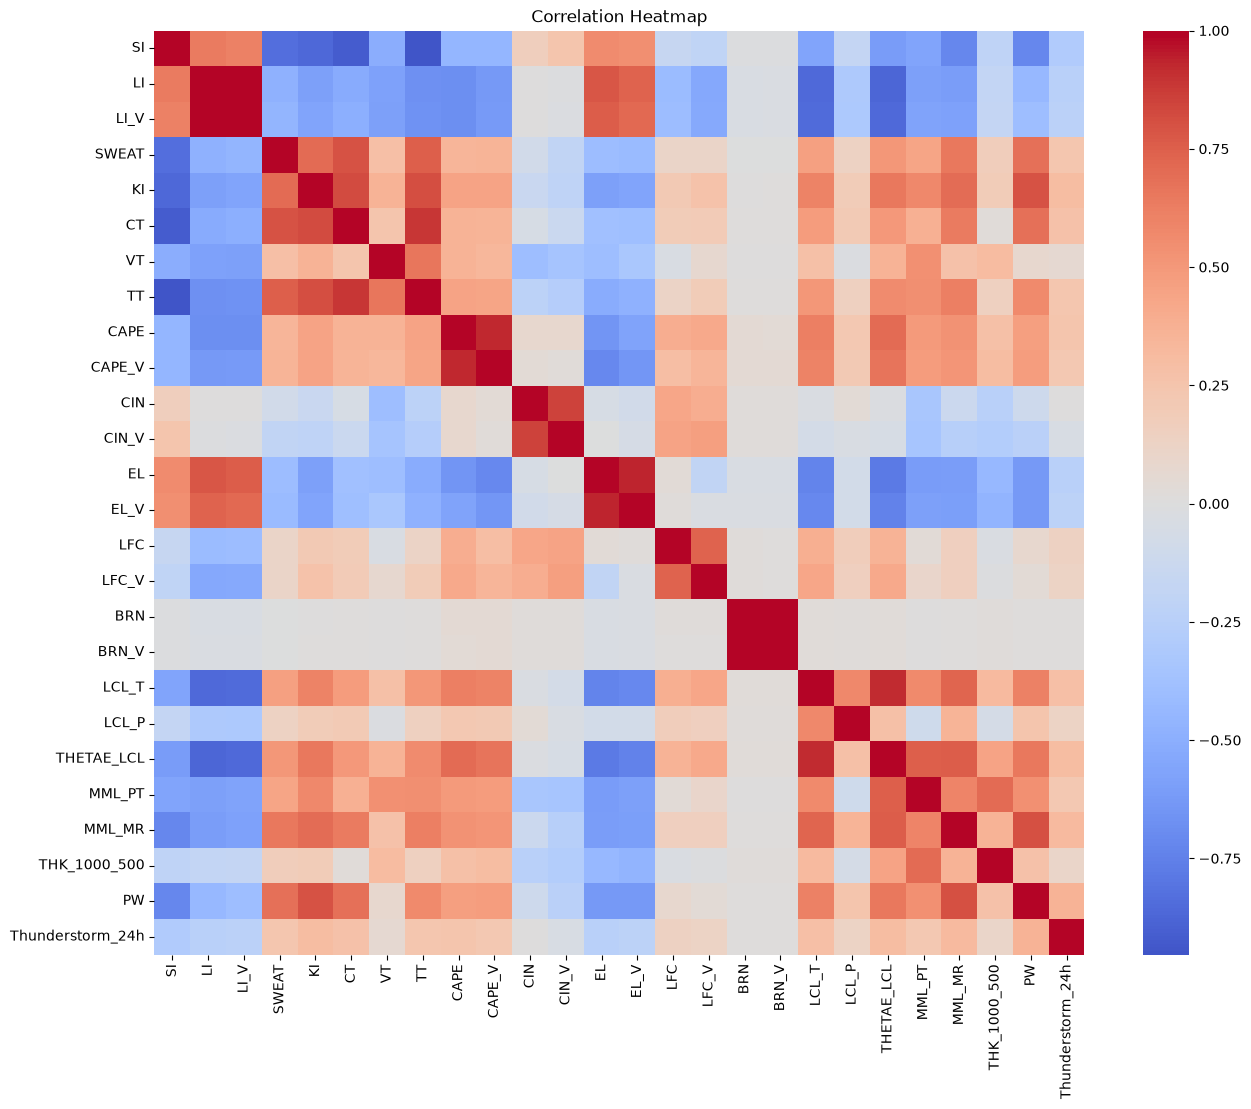

In [14]:
plt.figure(figsize=(15,12))

corr = train_df.corr(numeric_only=True)

sns.heatmap(

corr,

cmap="coolwarm",

center=0

)

plt.title("Correlation Heatmap")

plt.show()


In [15]:
corr_matrix = corr.abs()

upper = corr_matrix.where(

np.triu(

np.ones(corr_matrix.shape),

k=1

).astype(bool)

)

high_corr = [

column

for column in upper.columns

if any(

upper[column]>0.8

)

]

print(high_corr)

['LI_V', 'SWEAT', 'KI', 'CT', 'TT', 'CAPE_V', 'CIN_V', 'EL_V', 'BRN_V', 'LCL_T', 'THETAE_LCL', 'PW']


In [16]:
target_corr = corr["Thunderstorm_24h"]

target_corr = target_corr.sort_values(

ascending=False

)

display(target_corr)

Thunderstorm_24h    1.000000
PW                  0.360505
MML_MR              0.320732
THETAE_LCL          0.305620
KI                  0.304368
LCL_T               0.285193
CT                  0.271474
CAPE                0.247041
TT                  0.242921
SWEAT               0.239179
CAPE_V              0.225771
MML_PT              0.221812
LFC                 0.140508
LCL_P               0.127869
LFC_V               0.123478
THK_1000_500        0.100007
VT                  0.068395
BRN                 0.013751
BRN_V               0.011066
CIN                 0.003106
CIN_V              -0.040720
EL_V               -0.226499
LI_V               -0.235476
EL                 -0.246019
LI                 -0.248216
SI                 -0.292541
Name: Thunderstorm_24h, dtype: float64

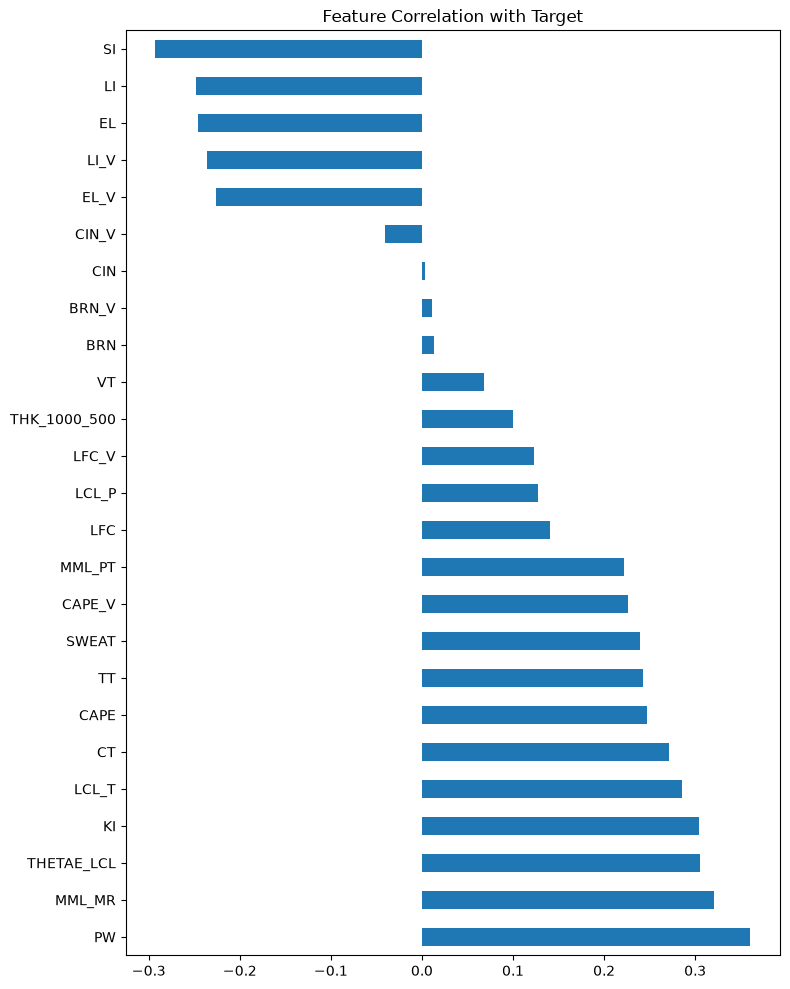

In [17]:
plt.figure(figsize=(8,10))

target_corr.drop(

"Thunderstorm_24h"

).plot(

kind="barh"

)

plt.title("Feature Correlation with Target")

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# MISSING VALUES
# ============================================================

missing = train_df.isnull().sum()

missing = missing[missing>0]

missing = missing.sort_values(ascending=False)

display(missing)

EL_V            6345
EL              6068
THK_1000_500    5680
BRN             2354
BRN_V           2354
SWEAT           2035
LFC             1650
SI              1618
LI              1618
KI              1618
TT              1618
VT              1618
CT              1618
LI_V            1618
LFC_V           1574
MML_MR            67
MML_PT            67
CAPE              31
CIN               31
CIN_V             31
CAPE_V            31
THETAE_LCL        31
LCL_P             31
LCL_T             31
PW                31
dtype: int64

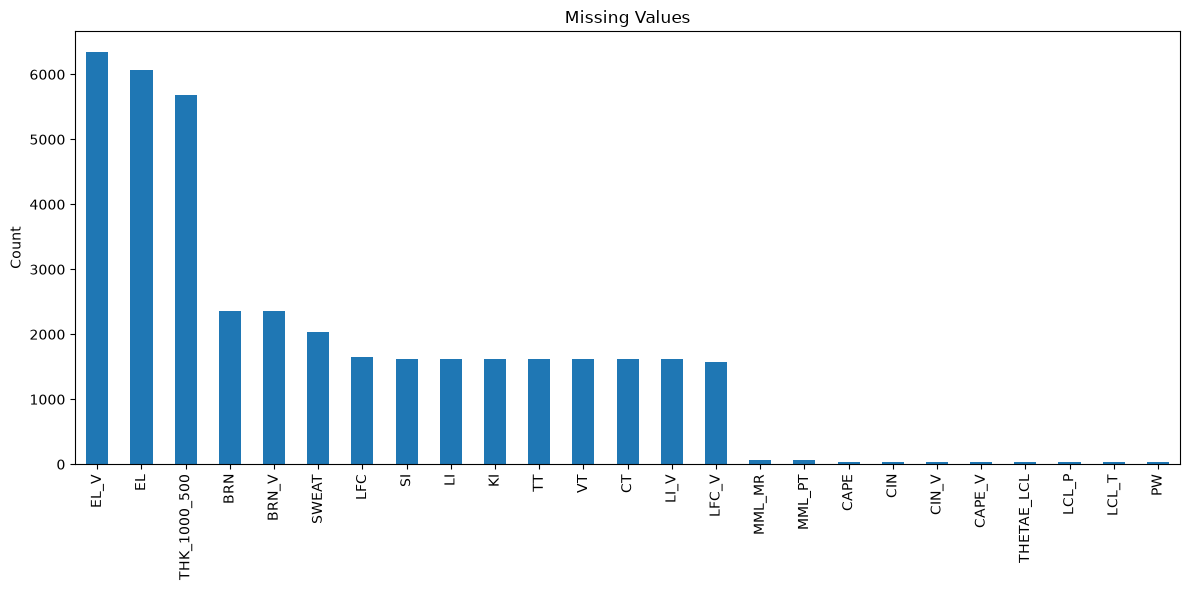

In [19]:
plt.figure(figsize=(12,6))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [20]:
duplicates = train_df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [21]:
dtype_df = pd.DataFrame({

"Column":train_df.columns,

"Datatype":train_df.dtypes

})

display(dtype_df)

,Column,Datatype
Date,Date,str
Time,Time,str
SI,SI,float64
LI,LI,float64
LI_V,LI_V,float64
SWEAT,SWEAT,float64
KI,KI,float64
CT,CT,float64
VT,VT,float64
TT,TT,float64


In [ ]:
S